In [16]:
import numpy as np
import matplotlib.pyplot as plt

# XOR input and labels
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([[0], [1], [1], [0]])


In [17]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

In [18]:
np.random.seed(1)

W1 = np.random.randn(2, 3)   # 3 hidden neurons
b1 = np.array([[0.1, -0.1, 0.2]])  # asymmetric biases

W2 = np.random.randn(3, 1)
b2 = np.zeros((1, 1))

In [19]:
learning_rate = 0.5
epochs = 10000
losses = []

for epoch in range(epochs):
    
    # ----- Forward Pass -----
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)
    
    z2 = np.dot(a1, W2) + b2
    y_hat = sigmoid(z2)
    
    # ----- Binary Cross-Entropy Loss -----
    eps = 1e-8
    loss = -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))
    losses.append(loss)
    
    # ----- Backpropagation -----
    d_z2 = y_hat - y
    
    d_W2 = np.dot(a1.T, d_z2)
    d_b2 = np.sum(d_z2, axis=0, keepdims=True)
    
    d_a1 = np.dot(d_z2, W2.T)
    d_z1 = d_a1 * sigmoid_derivative(z1)
    
    d_W1 = np.dot(X.T, d_z1)
    d_b1 = np.sum(d_z1, axis=0, keepdims=True)
    
    # ----- Update -----
    W2 -= learning_rate * d_W2
    b2 -= learning_rate * d_b2
    
    W1 -= learning_rate * d_W1
    b1 -= learning_rate * d_b1
    
    if epoch % 2000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")


Epoch 0, Loss: 0.797462
Epoch 2000, Loss: 0.002590
Epoch 4000, Loss: 0.001220
Epoch 6000, Loss: 0.000797
Epoch 8000, Loss: 0.000591


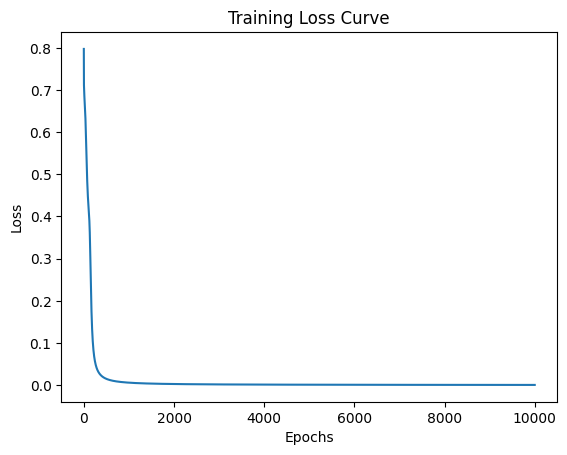

In [20]:
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [21]:
print("\nFinal Predictions:")
for i in range(len(X)):
    print(f"Input: {X[i]} → Predicted: {y_hat[i][0]:.4f}")


Final Predictions:
Input: [0 0] → Predicted: 0.0001
Input: [0 1] → Predicted: 0.9996
Input: [1 0] → Predicted: 0.9996
Input: [1 1] → Predicted: 0.0010
